In [2]:
# Monkey patch to inject distutils into memory, preventing ModuleNotFoundError 
# when running older packages on Python 3.12+
#................................................................
import sys
import types
from setuptools import _distutils

# sys.modules["distutils"] = types.ModuleType("distutils")
# sys.modules["distutils.version"] = _distutils.version
# sys.modules["distutils.core"] = _distutils.core
# sys.modules["distutils.dist"] = _distutils.dist
# sys.modules["distutils.command"] = _distutils.command
# sys.modules["distutils.sysconfig"] = _distutils.sysconfig
#................................................................
import tensorflow as tf
import tensorflow_decision_forests as tfdf
import pandas as pd
import seaborn as sns
import matplotlib.pyplot as plt

# Comment this if the data visualisations doesn't work on your side
%matplotlib inline

import numpy as np
import pandas as pd

import matplotlib.pyplot as plt
import seaborn as sns

from scipy.stats import skew
from scipy.special import boxcox1p

from sklearn.pipeline import make_pipeline
from sklearn.preprocessing import RobustScaler
from sklearn.linear_model import Lasso, ElasticNet, Ridge
from sklearn.kernel_ridge import KernelRidge
from sklearn.ensemble import GradientBoostingRegressor

# from xgboost import XGBRegressor
from lightgbm import LGBMRegressor

RANDOM_STATE = 42

2026-08-09 15:50:38.472206: I tensorflow/core/platform/cpu_feature_guard.cc:210] This TensorFlow binary is optimized to use available CPU instructions in performance-critical operations.
To enable the following instructions: AVX2 FMA, in other operations, rebuild TensorFlow with the appropriate compiler flags.


In [3]:
print("TensorFlow v" + tf.__version__)
print("TensorFlow Decision Forests v" + tfdf.__version__)

TensorFlow v2.16.2
TensorFlow Decision Forests v1.9.0


In [4]:
#Loading the dataset
train_data = pd.read_csv('./Dataset/train.csv')
test_data = pd.read_csv('./Dataset/test.csv')

In [5]:
#overview of the dataset
train_data.head()

,Id,MSSubClass,MSZoning,LotFrontage,LotArea,Street,Alley,LotShape,LandContour,Utilities,...,PoolArea,PoolQC,Fence,MiscFeature,MiscVal,MoSold,YrSold,SaleType,SaleCondition,SalePrice
0,1,60,RL,65.0,8450,Pave,NaN,Reg,Lvl,AllPub,...,0,NaN,NaN,NaN,0,2,2008,WD,Normal,208500
1,2,20,RL,80.0,9600,Pave,NaN,Reg,Lvl,AllPub,...,0,NaN,NaN,NaN,0,5,2007,WD,Normal,181500
2,3,60,RL,68.0,11250,Pave,NaN,IR1,Lvl,AllPub,...,0,NaN,NaN,NaN,0,9,2008,WD,Normal,223500
3,4,70,RL,60.0,9550,Pave,NaN,IR1,Lvl,AllPub,...,0,NaN,NaN,NaN,0,2,2006,WD,Abnorml,140000
4,5,60,RL,84.0,14260,Pave,NaN,IR1,Lvl,AllPub,...,0,NaN,NaN,NaN,0,12,2008,WD,Normal,250000


In [6]:
train_data.info()

<class 'pandas.DataFrame'>
RangeIndex: 1460 entries, 0 to 1459
Data columns (total 81 columns):
 #   Column         Non-Null Count  Dtype  
---  ------         --------------  -----  
 0   Id             1460 non-null   int64  
 1   MSSubClass     1460 non-null   int64  
 2   MSZoning       1460 non-null   str    
 3   LotFrontage    1201 non-null   float64
 4   LotArea        1460 non-null   int64  
 5   Street         1460 non-null   str    
 6   Alley          91 non-null     str    
 7   LotShape       1460 non-null   str    
 8   LandContour    1460 non-null   str    
 9   Utilities      1460 non-null   str    
 10  LotConfig      1460 non-null   str    
 11  LandSlope      1460 non-null   str    
 12  Neighborhood   1460 non-null   str    
 13  Condition1     1460 non-null   str    
 14  Condition2     1460 non-null   str    
 15  BldgType       1460 non-null   str    
 16  HouseStyle     1460 non-null   str    
 17  OverallQual    1460 non-null   int64  
 18  OverallCond    1460

In [7]:
train_data['SalePrice'].describe()

count      1460.000000
mean     180921.195890
std       79442.502883
min       34900.000000
25%      129975.000000
50%      163000.000000
75%      214000.000000
max      755000.000000
Name: SalePrice, dtype: float64

In [8]:
#overview of the missing values in the dataset
missing = train_data.isnull().sum()
missing = missing[missing > 0].sort_values(ascending=False)

missing_table = pd.DataFrame({'Missing Count': missing, 'Missing Percent': (missing / len(train_data) * 100).round(2)})

missing_table.head(15)

,Missing Count,Missing Percent
PoolQC,1453,99.52
MiscFeature,1406,96.30
Alley,1369,93.77
Fence,1179,80.75
MasVnrType,872,59.73
FireplaceQu,690,47.26
LotFrontage,259,17.74
GarageType,81,5.55
GarageYrBlt,81,5.55
GarageFinish,81,5.55


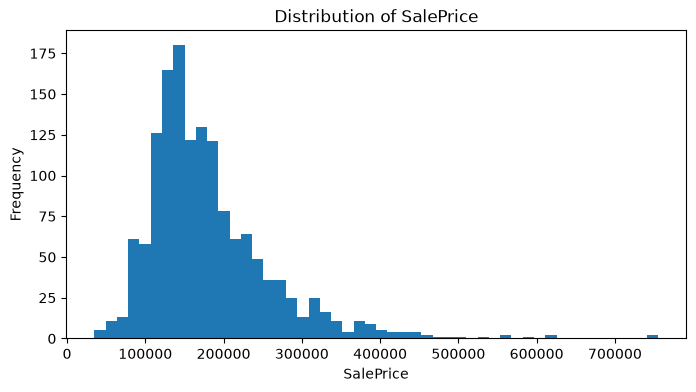

In [9]:
#checking the distribution of the target variable
plt.figure(figsize=(8, 4))
plt.hist(train_data['SalePrice'], bins=50)
plt.title('Distribution of SalePrice')
plt.xlabel('SalePrice')
plt.ylabel('Frequency')
plt.show()

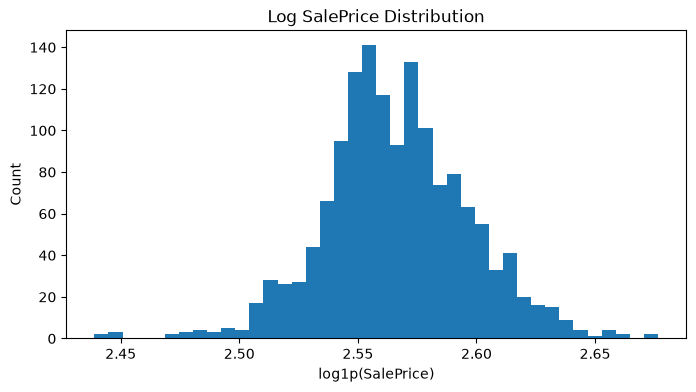

In [12]:
#normalizing the target variable
import numpy as np
y = np.log1p(train_data['SalePrice']).values
y_transformed = np.log1p(y)
plt.figure(figsize=(8, 4))
plt.hist(y_transformed, bins=40)
plt.title('Log SalePrice Distribution')
plt.xlabel('log1p(SalePrice)')
plt.ylabel('Count')
plt.show()

In [13]:
#we can see more charts to understand the data better. For example, we can plot the relationship between the overall quality of the house and the sale price. This will help us learn more about the data and how the features relate to the target variable.

In [14]:
#finding correlation between features and target variable
corr_matrix = train_data.select_dtypes(include=[np.number]).corr()['SalePrice'].sort_values(ascending=False)
corr_matrix.head(10)

SalePrice       1.000000
OverallQual     0.790982
GrLivArea       0.708624
GarageCars      0.640409
GarageArea      0.623431
TotalBsmtSF     0.613581
1stFlrSF        0.605852
FullBath        0.560664
TotRmsAbvGrd    0.533723
YearBuilt       0.522897
Name: SalePrice, dtype: float64

## The Mideling Pipeline
- removing outliers and uninformative featrue (e.g ID)
- Applying log1p to Salesprice for normalizing the value of this feature
- Handdeling missing values
- Creating new features (feature engineering phase)
- Encoding columns with string value and assign numerical values to them
- Training several models
- Blending different model's prediction (ensemble learning technique)

In [15]:
#making a copy of the dataset to work on it
train_data_copy = train_data.copy()
test_data_copy = test_data.copy()


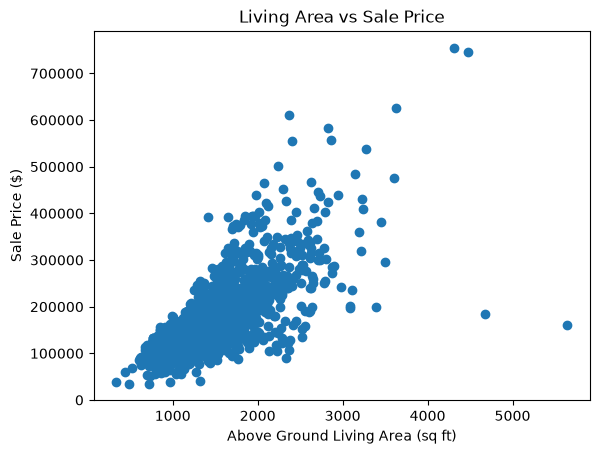

In [16]:
#finding outlier
import matplotlib.pyplot as plt

plt.scatter(x=train_data['GrLivArea'], y=train_data['SalePrice'])
plt.xlabel('Above Ground Living Area (sq ft)')
plt.ylabel('Sale Price ($)')
plt.title('Living Area vs Sale Price')
plt.show()

In [46]:
# # 1. Calculate Q1 and Q3 for the feature
# Q1 = train_data_copy['GrLivArea'].quantile(0.25)
# Q3 = train_data_copy['GrLivArea'].quantile(0.75)
# IQR = Q3 - Q1

# # 2. Calculate the upper and lower fences
# lower_fence = Q1 - (1.5 * IQR)
# upper_fence = Q3 + (1.5 * IQR)

# # 3. Filter the dataset to keep only the houses INSIDE the fences
# train_data_clean = train_data_copy[(train_data_copy['GrLivArea'] >= lower_fence) & (train_data_copy['GrLivArea'] <= upper_fence)]

# train_data_clean = train_data_copy[
#     (train_data_copy['GrLivArea'] >= lower_fence) &
#     (train_data_copy['GrLivArea'] <= upper_fence)
# ]

# X = train_data_clean.drop('SalePrice', axis=1)
# y = train_data_clean['SalePrice']

# print(X.shape)
# print(y.shape)

# print(f"Original dataset size: {train_data_copy.shape[0]} rows")
# print(f"Cleaned dataset size: {train_data_clean.shape[0]} rows")

# 1. Calculate Q1 and Q3 for the feature
Q1 = train_data_copy['GrLivArea'].quantile(0.25)
Q3 = train_data_copy['GrLivArea'].quantile(0.75)
IQR = Q3 - Q1

# 2. Calculate the upper and lower fences
lower_fence = Q1 - (1.5 * IQR)
upper_fence = Q3 + (1.5 * IQR)

# 3. Filter the dataset to keep only the houses INSIDE the fences
train_data_clean = train_data_copy[
    (train_data_copy['GrLivArea'] >= lower_fence) &
    (train_data_copy['GrLivArea'] <= upper_fence)
].copy()

print(f"Original dataset size: {train_data_copy.shape[0]} rows")
print(f"Cleaned dataset size: {train_data_clean.shape[0]} rows")

# 4. Create X and y from the cleaned dataset
X = train_data_clean.drop('SalePrice', axis=1)
y = train_data_clean['SalePrice']

print(f"X shape: {X.shape}")
print(f"y shape: {y.shape}")

Original dataset size: 1460 rows
Cleaned dataset size: 1429 rows
X shape: (1429, 80)
y shape: (1429,)


In [18]:
#removing outliers from the dataset based on the 'GrLivArea' feature. We will remove houses with a 'GrLivArea' greater than 4000 square feet, as they are considered outliers and can negatively impact the model's performance.
# train_data_copy = train_data_copy[train_data_copy['GrLivArea'] < 4000]
# test_data_copy = test_data_copy[test_data_copy['GrLivArea'] < 4000]

In [19]:
#applying log transformation to the target variable
train_data_copy['SalePrice'] = np.log1p(train_data_copy['SalePrice'])

In [20]:
all_data = pd.concat([train_data_clean.drop('SalePrice', axis=1), test_data_copy], axis=0, ignore_index=True)
all_data = all_data.drop('Id', axis=1)

print('Train after outlier removal:', train_data_copy.shape)
print('Combined data shape:', all_data.shape)

Train after outlier removal: (1460, 81)
Combined data shape: (2888, 79)


In [21]:
#handeling missing values
# Missing categorical values where NA means the feature does not exist
non_columns = [
    'PoolQC', 'MiscFeature', 'Alley', 'Fence', 'FireplaceQu',
    'GarageType', 'GarageFinish', 'GarageQual', 'GarageCond',
    'BsmtQual', 'BsmtCond', 'BsmtExposure', 'BsmtFinType1', 'BsmtFinType2',
    'MasVnrType'
]

for col in non_columns:
    if col in all_data.columns:
        all_data[col] = all_data[col].fillna('None')

# Missing numeric values where zero is meaningful
zero_columns = [
    'GarageYrBlt', 'GarageArea', 'GarageCars',
    'BsmtFinSF1', 'BsmtFinSF2', 'BsmtUnfSF', 'TotalBsmtSF',
    'BsmtFullBath', 'BsmtHalfBath', 'MasVnrArea'
]

for col in zero_columns:
    if col in all_data.columns:
        all_data[col] = all_data[col].fillna(0)

# LotFrontage is filled by the median of each Neighborhood
all_data['LotFrontage'] = all_data.groupby('Neighborhood')['LotFrontage'].transform(
    lambda x: x.fillna(x.median())
)
all_data['LotFrontage'] = all_data['LotFrontage'].fillna(all_data['LotFrontage'].median())

# Other real missing categorical values
for col in ['MSZoning', 'Electrical', 'KitchenQual', 'Exterior1st', 'Exterior2nd', 'SaleType']:
    if col in all_data.columns:
        all_data[col] = all_data[col].fillna(all_data[col].mode()[0])

if 'Functional' in all_data.columns:
    all_data['Functional'] = all_data['Functional'].fillna('Typ')

# Utilities is almost constant, so we remove it
if 'Utilities' in all_data.columns:
    all_data = all_data.drop('Utilities', axis=1)

# Fill anything still missing
for col in all_data.select_dtypes(exclude='object').columns:
    all_data[col] = all_data[col].fillna(all_data[col].median())

for col in all_data.select_dtypes(include='object').columns:
    all_data[col] = all_data[col].fillna(all_data[col].mode()[0])

print('Remaining missing values:', all_data.isnull().sum().sum())

Remaining missing values: 0


/var/folders/gk/q9d5jbtj33j94vb3kz2vgk4h0000gn/T/ipykernel_1295/1617492332.py:47: Pandas4Warning: For backward compatibility, 'str' dtypes are included by select_dtypes when 'object' dtype is specified. This behavior is deprecated and will be removed in a future version. Explicitly pass 'str' to `include` to select them, or to `exclude` to remove them and silence this warning.
See https://pandas.pydata.org/docs/user_guide/migration-3-strings.html#string-migration-select-dtypes for details on how to write code that works with pandas 2 and 3.
  for col in all_data.select_dtypes(include='object').columns:


In [23]:
# These columns are numbers, but they represent categories
for col in ['MSSubClass', 'MoSold', 'YrSold']:
    if col in all_data.columns:
        all_data[col] = all_data[col].astype(str)

quality_map = {'None': 0, 'Po': 1, 'Fa': 2, 'TA': 3, 'Gd': 4, 'Ex': 5}

quality_cols = [
    'ExterQual', 'ExterCond', 'BsmtQual', 'BsmtCond', 'HeatingQC',
    'KitchenQual', 'FireplaceQu', 'GarageQual', 'GarageCond', 'PoolQC'
]

for col in quality_cols:
    if col in all_data.columns:
        all_data[col] = all_data[col].map(quality_map).fillna(0).astype(int)

ordinal_maps = {
    'BsmtExposure': {'None': 0, 'No': 1, 'Mn': 2, 'Av': 3, 'Gd': 4},
    'BsmtFinType1': {'None': 0, 'Unf': 1, 'LwQ': 2, 'Rec': 3, 'BLQ': 4, 'ALQ': 5, 'GLQ': 6},
    'BsmtFinType2': {'None': 0, 'Unf': 1, 'LwQ': 2, 'Rec': 3, 'BLQ': 4, 'ALQ': 5, 'GLQ': 6},
    'Functional': {'Sal': 1, 'Sev': 2, 'Maj2': 3, 'Maj1': 4, 'Mod': 5, 'Min2': 6, 'Min1': 7, 'Typ': 8},
    'GarageFinish': {'None': 0, 'Unf': 1, 'RFn': 2, 'Fin': 3},
    'PavedDrive': {'N': 0, 'P': 1, 'Y': 2},
    'LotShape': {'IR3': 1, 'IR2': 2, 'IR1': 3, 'Reg': 4},
    'LandSlope': {'Sev': 1, 'Mod': 2, 'Gtl': 3},
    'CentralAir': {'N': 0, 'Y': 1},
    'Fence': {'None': 0, 'MnWw': 1, 'GdWo': 2, 'MnPrv': 3, 'GdPrv': 4}
}

for col, mapping in ordinal_maps.items():
    if col in all_data.columns:
        all_data[col] = all_data[col].map(mapping).fillna(0).astype(int)

In [24]:
#feature engineering
# Create new features based on existing ones
YrSold_int = all_data['YrSold'].astype(int)

all_data['TotalSF'] = all_data['TotalBsmtSF'] + all_data['1stFlrSF'] + all_data['2ndFlrSF']
all_data['TotalBath'] = all_data['FullBath'] + 0.5 * all_data['HalfBath'] + all_data['BsmtFullBath'] + 0.5 * all_data['BsmtHalfBath']
all_data['TotalPorchSF'] = all_data['OpenPorchSF'] + all_data['EnclosedPorch'] + all_data['3SsnPorch'] + all_data['ScreenPorch'] + all_data['WoodDeckSF']

all_data['HouseAge'] = YrSold_int - all_data['YearBuilt']
all_data['RemodAge'] = YrSold_int - all_data['YearRemodAdd']
all_data['GarageAge'] = np.where(all_data['GarageYrBlt'] > 0, YrSold_int - all_data['GarageYrBlt'], 0)

all_data['IsRemodeled'] = (all_data['YearBuilt'] != all_data['YearRemodAdd']).astype(int)
all_data['IsNew'] = (all_data['YearBuilt'] == YrSold_int).astype(int)

all_data['HasGarage'] = (all_data['GarageArea'] > 0).astype(int)
all_data['HasBasement'] = (all_data['TotalBsmtSF'] > 0).astype(int)
all_data['HasFireplace'] = (all_data['Fireplaces'] > 0).astype(int)
all_data['HasPool'] = (all_data['PoolArea'] > 0).astype(int)
all_data['Has2ndFloor'] = (all_data['2ndFlrSF'] > 0).astype(int)
all_data['HasWoodDeck'] = (all_data['WoodDeckSF'] > 0).astype(int)
all_data['HasOpenPorch'] = (all_data['OpenPorchSF'] > 0).astype(int)
all_data['HasMasVnr'] = (all_data['MasVnrArea'] > 0).astype(int)

all_data['TotalQual'] = all_data['OverallQual'] + all_data['OverallCond']
all_data['QualSF'] = all_data['OverallQual'] * all_data['TotalSF']
all_data['QualGrLiv'] = all_data['OverallQual'] * all_data['GrLivArea']
all_data['QualBath'] = all_data['OverallQual'] * all_data['TotalBath']
all_data['QualGarage'] = all_data['OverallQual'] * all_data['GarageCars']
all_data['BsmtQualSF'] = all_data['BsmtQual'] * all_data['TotalBsmtSF']
all_data['GarageQualArea'] = all_data['GarageQual'] * all_data['GarageArea']
all_data['KitchenQualSF'] = all_data['KitchenQual'] * all_data['TotalSF']
all_data['ExterQualSF'] = all_data['ExterQual'] * all_data['TotalSF']

In [25]:
df_num = train_data_clean.select_dtypes(include = ['float64', 'int64'])

array([[<Axes: title={'center': 'Id'}>,
        <Axes: title={'center': 'MSSubClass'}>,
        <Axes: title={'center': 'LotFrontage'}>,
        <Axes: title={'center': 'LotArea'}>,
        <Axes: title={'center': 'OverallQual'}>,
        <Axes: title={'center': 'OverallCond'}>],
       [<Axes: title={'center': 'YearBuilt'}>,
        <Axes: title={'center': 'YearRemodAdd'}>,
        <Axes: title={'center': 'MasVnrArea'}>,
        <Axes: title={'center': 'BsmtFinSF1'}>,
        <Axes: title={'center': 'BsmtFinSF2'}>,
        <Axes: title={'center': 'BsmtUnfSF'}>],
       [<Axes: title={'center': 'TotalBsmtSF'}>,
        <Axes: title={'center': '1stFlrSF'}>,
        <Axes: title={'center': '2ndFlrSF'}>,
        <Axes: title={'center': 'LowQualFinSF'}>,
        <Axes: title={'center': 'GrLivArea'}>,
        <Axes: title={'center': 'BsmtFullBath'}>],
       [<Axes: title={'center': 'BsmtHalfBath'}>,
        <Axes: title={'center': 'FullBath'}>,
        <Axes: title={'center': 'HalfBath'}>,

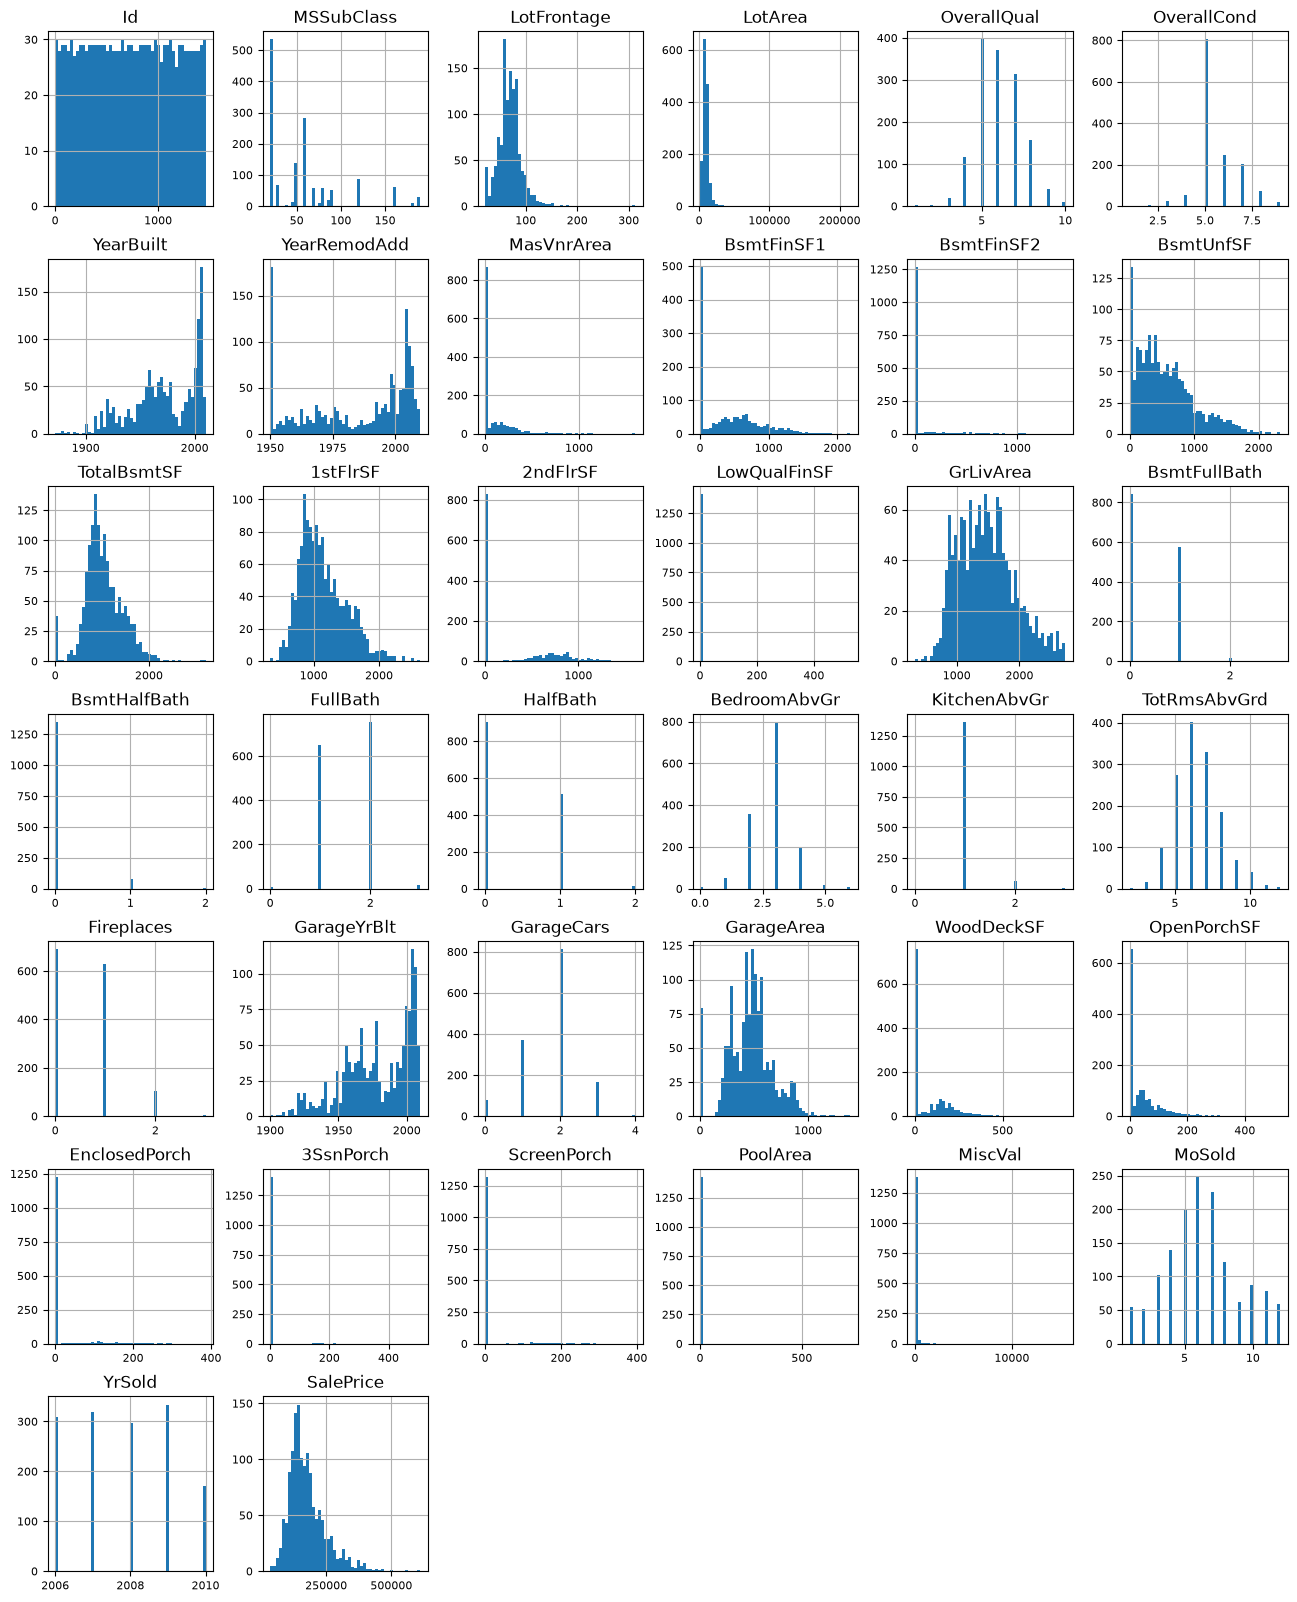

In [26]:
df_num.hist(figsize=(16, 20), bins=50, xlabelsize=8, ylabelsize=8)

In [35]:
#skewed features and one-hot encoding
# numeric_features = all_data.dtypes[all_data.dtypes != 'object'].index
# skew_values = all_data[numeric_features].apply(lambda x: skew(x.dropna()))
# skewed_features = skew_values[abs(skew_values) > 0.75].index
numeric_features = all_data.select_dtypes(exclude=['object']).columns

skew_values = all_data[numeric_features].apply(
    lambda x: skew(x.dropna())
)

skewed_features = skew_values[abs(skew_values) > 0.75].index

for col in skewed_features:
    all_data[col] = np.log1p(all_data[col])

for col in skewed_features:
    if all_data[col].min() < 0:
        all_data[col] = all_data[col] - all_data[col].min()
    all_data[col] = boxcox1p(all_data[col], 0.15)

all_data = pd.get_dummies(all_data)

n_train = len(train_data_clean)
X = all_data.iloc[:n_train].copy()
X_test = all_data.iloc[n_train:].copy()

X, X_test = X.align(X_test, join='left', axis=1, fill_value=0)

print('Final train shape:', X.shape)
print('Final test shape :', X_test.shape)
print('Number of transformed skewed features:', len(skewed_features))

Final train shape: (1429, 276)
Final test shape : (1459, 276)
Number of transformed skewed features: 221


In [37]:
from xgboost import XGBRegressor
from lightgbm import LGBMRegressor

#defining the models
models = {
    'lasso': make_pipeline(
        RobustScaler(),
        Lasso(alpha=0.00042, random_state=RANDOM_STATE, max_iter=20000)
    ),
    'enet': make_pipeline(
        RobustScaler(),
        ElasticNet(alpha=0.00048, l1_ratio=0.86, random_state=RANDOM_STATE, max_iter=20000)
    ),
    'ridge': make_pipeline(
        RobustScaler(),
        Ridge(alpha=9.0, random_state=RANDOM_STATE)
    ),
    'krr': make_pipeline(
        RobustScaler(),
        KernelRidge(alpha=0.60, kernel='polynomial', degree=2, coef0=2.5)
    ),
    'gbr': GradientBoostingRegressor(
        n_estimators=900,
        learning_rate=0.035,
        max_depth=4,
        max_features='sqrt',
        min_samples_leaf=15,
        min_samples_split=10,
        loss='huber',
        random_state=RANDOM_STATE
    ),
    'xgb': XGBRegressor(
        n_estimators=900,
        learning_rate=0.025,
        max_depth=3,
        min_child_weight=2,
        subsample=0.75,
        colsample_bytree=0.75,
        reg_alpha=0.0004,
        reg_lambda=1.0,
        objective='reg:squarederror',
        random_state=RANDOM_STATE,
        n_jobs=2,
        verbosity=0
    ),
    'lgbm': LGBMRegressor(
        objective='regression',
        num_leaves=5,
        learning_rate=0.025,
        n_estimators=1100,
        max_bin=90,
        bagging_fraction=0.8,
        bagging_freq=5,
        feature_fraction=0.25,
        min_data_in_leaf=6,
        min_sum_hessian_in_leaf=11,
        random_state=RANDOM_STATE,
        n_jobs=2,
        verbose=-1
    )
}

weights = {
    'lasso': 0.16880338552954197,
    'enet': 0.16718708540685231,
    'ridge': 0.04701030923263547,
    'krr': 0.19149982997569610,
    'gbr': 0.14500010018665793,
    'xgb': 0.14849726451308384,
    'lgbm': 0.13200202515553244
}

In [47]:
#cross-validation function to evaluate the models
from sklearn.model_selection import KFold, cross_val_score
from sklearn.metrics import mean_squared_error

cross_val = KFold(n_splits=5, shuffle=True, random_state=RANDOM_STATE)

def rmse_cv(model):
    scores = cross_val_score(
        model, X, y,
        scoring='neg_mean_squared_error',
        cv=cross_val,
        n_jobs=-1
    )
    return np.sqrt(-scores)

cv_results = []
for name, model in models.items():
    scores = rmse_cv(model)
    cv_results.append({
        'Model': name,
        'Mean RMSE': scores.mean(),
        'Std RMSE': scores.std()
    })
    print(f'{name}: {scores.mean():.5f} (+/- {scores.std():.5f})')

cv_results_df = pd.DataFrame(cv_results).sort_values('Mean RMSE')
cv_results_df

ValueError: 
All the 5 fits failed.
It is very likely that your model is misconfigured.
You can try to debug the error by setting error_score='raise'.

Below are more details about the failures:
--------------------------------------------------------------------------------
5 fits failed with the following error:
Traceback (most recent call last):
  File "/Users/macbook/Documents/Code/Machine-Learning-Projects/tf-env/lib/python3.11/site-packages/sklearn/model_selection/_validation.py", line 856, in _fit_and_score
    estimator.fit(X_train, y_train, **fit_params)
  File "/Users/macbook/Documents/Code/Machine-Learning-Projects/tf-env/lib/python3.11/site-packages/sklearn/base.py", line 1403, in wrapper
    return fit_method(estimator, *args, **kwargs)
           ^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^
  File "/Users/macbook/Documents/Code/Machine-Learning-Projects/tf-env/lib/python3.11/site-packages/sklearn/pipeline.py", line 636, in fit
    Xt = self._fit(
         ^^^^^^^^^^
  File "/Us